In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

print('import successful')

import successful


In [4]:
df = pd.read_csv('pokemon_clean.csv')

conn = sqlite3.connect('pokemon_clean.db')

print('Shape:', df.shape)
print('Connected to database')

Shape: (1025, 48)
Connected to database


In [7]:
regular = df[(df['Is_Legendary'] == 0) & (df['Is_Mythical'] ==0) & (df['Is_Ultra_Beast'] == 0)]

correlation = regular['Base_Stats'].corr(regular['gen'])

print(f'Correlation between Generation and Base stats: {correlation:.3f}')

Correlation between Generation and Base stats: 0.135


In [10]:
groups = [regular[regular['gen'] == gen]['Base_Stats'].values for gen in range(1,10)]
    
f_stat, p_value = stats.f_oneway(*groups)

print(f'F-statistic: {f_stat:3f}')
print(f'P-value: {p_value:.4f}')


F-statistic: 3.148614
P-value: 0.0016


In [16]:
legendary = df[(df['Is_Legendary'] == 1)]

legendary_correlation = legendary['Base_Stats'].corr(legendary['gen'])

print(f'Correlation between Generation and Legendary Base stats: {legendary_correlation:.3f}')

Correlation between Generation and Legendary Base stats: -0.260


In [15]:
legendary_groups = [legendary[legendary['gen'] == gen]['Base_Stats'].values for gen in range(1,10)]
    
f_stat, p_value = stats.f_oneway(*legendary_groups)

print(f'F-statistic: {f_stat:3f}')
print(f'P-value: {p_value:.4f}')


F-statistic: 1.378376
P-value: 0.2265


In [17]:
mythical = df[(df['Is_Mythical'] == 1)]

mythical_correlation = mythical['Base_Stats'].corr(mythical['gen'])

print(f'correlation between generation and mythical base stats: {mythical_correlation:.3f}')

correlation between generation and mythical base stats: -0.174


In [18]:
mythical_groups = [mythical[mythical['gen'] == gen]['Base_Stats'].values for gen in range(1,10)]
    
f_stat, p_value = stats.f_oneway(*mythical_groups)

print(f'F-statistic: {f_stat:3f}')
print(f'P-value: {p_value:.4f}')


F-statistic: 0.236238
P-value: 0.9768


In [21]:
contingency_table = pd.crosstab(df['Type 1'], df['Is_Legendary'])

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f'chi-2: {chi2}')
print(f'p value: {p_value}')
print(f'degrees of freedom: {dof}')
print(f'expected: {expected}')

chi-2: 56.65470408023591
p value: 3.7056144215867912e-06
degrees of freedom: 17
expected: [[ 77.81756098   5.18243902]
 [ 42.1902439    2.8097561 ]
 [ 34.6897561    2.3102439 ]
 [ 55.31609756   3.68390244]
 [ 27.18926829   1.81073171]
 [ 37.50243902   2.49756098]
 [ 61.87902439   4.12097561]
 [  8.43804878   0.56195122]
 [ 32.81463415   2.18536585]
 [ 96.56878049   6.43121951]
 [ 37.50243902   2.49756098]
 [ 29.06439024   1.93560976]
 [110.63219512   7.36780488]
 [ 39.37756098   2.62243902]
 [ 56.25365854   3.74634146]
 [ 54.37853659   3.62146341]
 [ 33.75219512   2.24780488]
 [125.63317073   8.36682927]]


In [24]:
print("observed counts:")
print(contingency_table)

observed = contingency_table.values
difference = observed - expected
diff_df = pd.DataFrame(difference,
                       index=contingency_table.index,
                       columns = ['Not Legendary', 'Legendary'])
print("\nDifference from expected (positive = more than expected):")
print(diff_df.sort_values('Legendary', ascending=False))

observed counts:
Is_Legendary    0   1
Type 1               
Bug            83   0
Dark           40   5
Dragon         29   8
Electric       54   5
Fairy          26   3
Fighting       36   4
Fire           62   4
Flying          8   1
Ghost          34   1
Grass         101   2
Ground         38   2
Ice            29   2
Normal        115   3
Poison         38   4
Psychic        48  12
Rock           56   2
Steel          33   3
Water         131   3

Difference from expected (positive = more than expected):
          Not Legendary  Legendary
Type 1                            
Psychic       -8.253659   8.253659
Dragon        -5.689756   5.689756
Dark          -2.190244   2.190244
Fighting      -1.502439   1.502439
Poison        -1.377561   1.377561
Electric      -1.316098   1.316098
Fairy         -1.189268   1.189268
Steel         -0.752195   0.752195
Flying        -0.438049   0.438049
Ice           -0.064390   0.064390
Fire           0.120976  -0.120976
Ground         0.497561  -0.4

In [25]:
print(diff_df.sort_values('Legendary', ascending=False))

          Not Legendary  Legendary
Type 1                            
Psychic       -8.253659   8.253659
Dragon        -5.689756   5.689756
Dark          -2.190244   2.190244
Fighting      -1.502439   1.502439
Poison        -1.377561   1.377561
Electric      -1.316098   1.316098
Fairy         -1.189268   1.189268
Steel         -0.752195   0.752195
Flying        -0.438049   0.438049
Ice           -0.064390   0.064390
Fire           0.120976  -0.120976
Ground         0.497561  -0.497561
Ghost          1.185366  -1.185366
Rock           1.621463  -1.621463
Normal         4.367805  -4.367805
Grass          4.431220  -4.431220
Bug            5.182439  -5.182439
Water          5.366829  -5.366829


In [28]:
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12

gen_colors = sns.color_palette('tab10', 9)

In [29]:
regular_avg = regular.groupby('gen')['Base_Stats'].mean()
legendary_avg = legendary.groupby('gen')['Base_Stats'].mean()
mythical_avg = mythical.groupby('gen')['Base_Stats'].mean()


print("regular:")
print(regular_avg)
print("\nlegendary:")
print(legendary_avg)
print("\nmythical")
print(mythical_avg)

regular:
gen
1    400.917808
2    393.808511
3    386.744000
4    419.849462
5    409.216783
6    411.666667
7    418.606061
8    420.825581
9    444.462963
Name: Base_Stats, dtype: float64

legendary:
gen
1    605.000000
2    620.000000
3    620.000000
4    627.777778
5    613.333333
6    653.333333
7    521.666667
8    578.333333
9    571.363636
Name: Base_Stats, dtype: float64

mythical
gen
1    600.0
2    600.0
3    600.0
4    600.0
5    595.0
6    600.0
7    540.0
8    600.0
9    600.0
Name: Base_Stats, dtype: float64


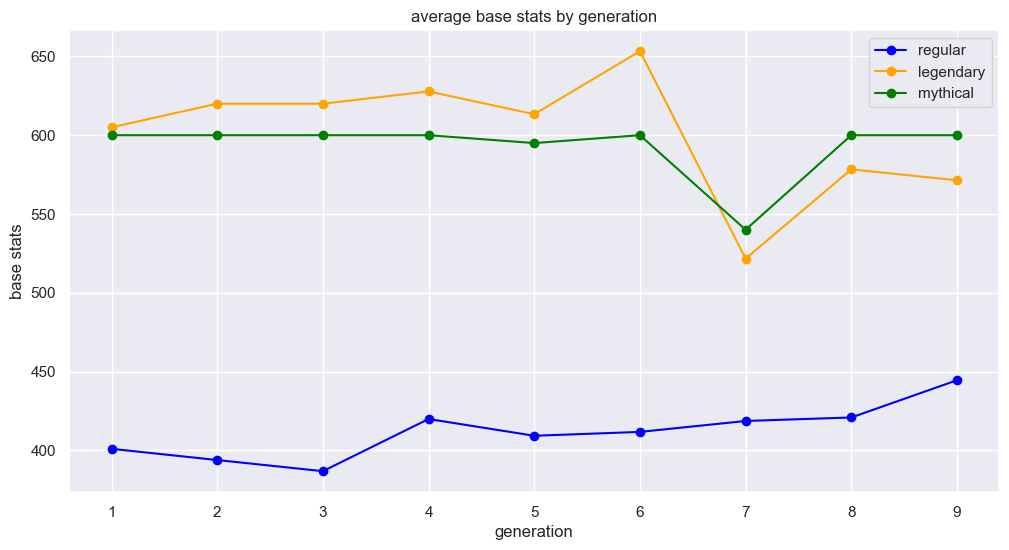

In [33]:


plt.plot(regular_avg.index, regular_avg.values, marker = 'o', label = 'regular', color = 'blue')
plt.plot(legendary_avg.index, legendary_avg.values, marker='o', label='legendary', color='orange')
plt.plot(mythical_avg.index, mythical_avg.values, marker = 'o', label='mythical', color='green')

plt.title('average base stats by generation')
plt.xlabel('generation')
plt.ylabel('base stats')
plt.legend()
plt.xticks(range(1, 10))
plt.savefig('/Users/prajwalhendre/Desktop/Pokemon_Project/avg_stats_by_gen.png', dpi=300, bbox_inches='tight')

plt.show()

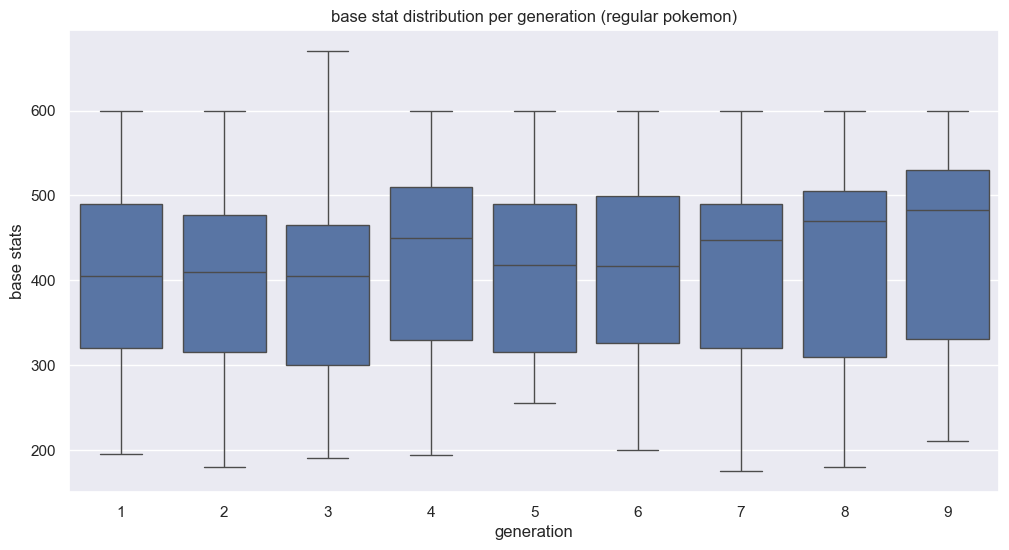

In [38]:
regular_box_plot = sns.boxplot(data=regular, x='gen', y='Base_Stats')

plt.title("base stat distribution per generation (regular pokemon)")
plt.xlabel('generation')
plt.ylabel('base stats')
plt.savefig('/Users/prajwalhendre/Desktop/Pokemon_Project/base_stat_distribution.png')
plt.show()

In [40]:
with open('type_counts_ratio.sql') as f:
    type_query = f.read()

type_df = pd.read_sql_query(type_query, conn)

print(type_df.head(10))

   gen     type  type_ratio
0    1   Poison        22.0
1    1    Water        21.0
2    1   Normal        15.0
3    1   Flying        13.0
4    1  Psychic         9.0
5    1   Ground         9.0
6    1    Grass         9.0
7    1     Fire         8.0
8    1      Bug         8.0
9    1     Rock         7.0


In [ ]:
type_pivot = type_df.pivot(index='gen', columns='type', values='type_ratio').fillna(0)
print(type_pivot.head())

#some pokemon retroactively classified

type   Bug  Dark  Dragon  Electric  Fairy  Fighting  Fire  Flying  Ghost  \
gen                                                                        
1      8.0   0.0     2.0       6.0    3.0       5.0   8.0    13.0    2.0   
2     10.0   6.0     1.0       8.0    8.0       3.0  10.0    19.0    1.0   
3     10.0   7.0     7.0       3.0    4.0       5.0   4.0     9.0    4.0   
4      8.0   7.0     6.0       7.0    2.0       7.0   5.0    13.0    7.0   
5     12.0  10.0     6.0       7.0    1.0      10.0  10.0    12.0    6.0   

type  Grass  Ground  Ice  Normal  Poison  Psychic  Rock  Steel  Water  
gen                                                                    
1       9.0     9.0  3.0    15.0    22.0      9.0   7.0    1.0   21.0  
2      10.0    10.0  5.0    15.0     4.0     10.0   7.0    4.0   18.0  
3      13.0    10.0  4.0    13.0     4.0     15.0   9.0    7.0   21.0  
4      13.0     9.0  6.0    16.0     7.0      8.0   7.0    9.0   13.0  
5      13.0     7.0  4.0    11.0   

<Figure size 1400x800 with 0 Axes>

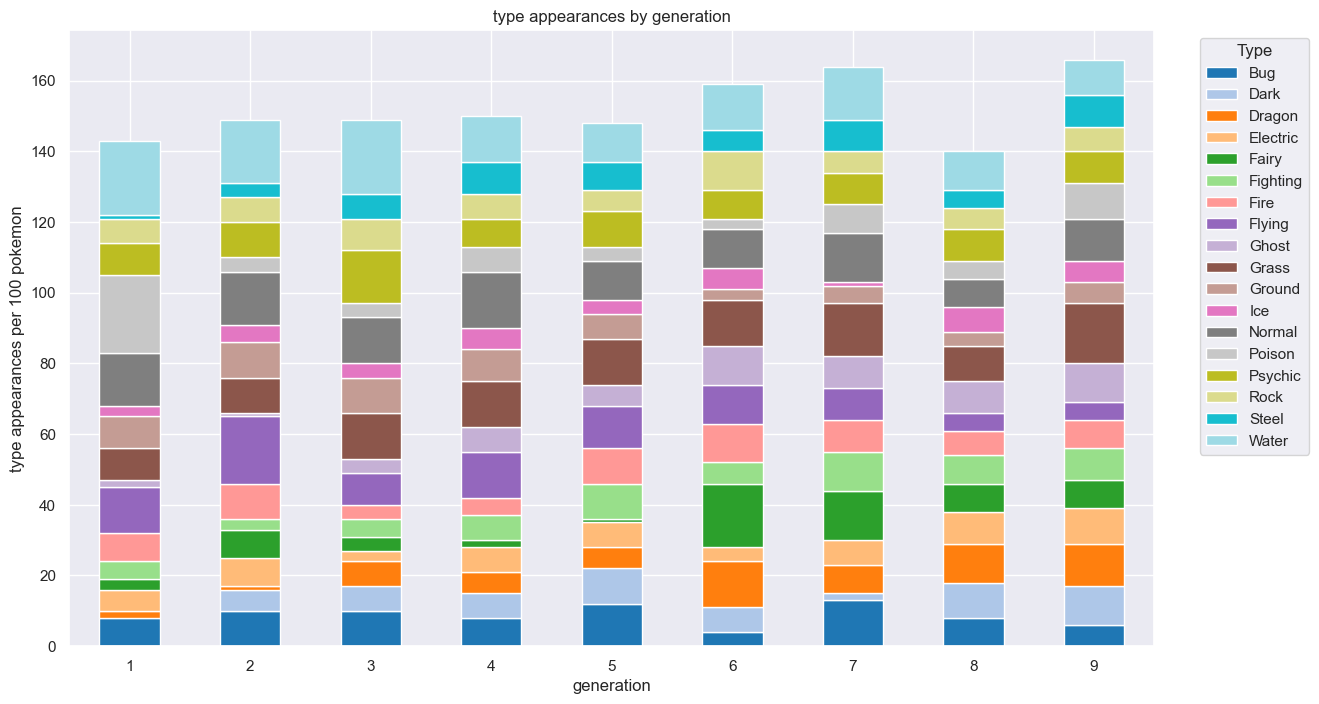

In [52]:
plt.figure(figsize=(14,8))

type_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    colormap='tab20'
)

plt.title('type appearances by generation')
plt.xlabel('generation')
plt.ylabel('type appearances per 100 pokemon')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), title='Type')

plt.xticks(rotation=0)
plt.savefig('/Users/prajwalhendre/Desktop/Pokemon_Project/type_appearances_by_gen.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
legendary_diff = diff_df['Legendary'].sort_values(ascending=True)
print(legendary_diff)

Type 1
Water      -5.366829
Bug        -5.182439
Grass      -4.431220
Normal     -4.367805
Rock       -1.621463
Ghost      -1.185366
Ground     -0.497561
Fire       -0.120976
Ice         0.064390
Flying      0.438049
Steel       0.752195
Fairy       1.189268
Electric    1.316098
Poison      1.377561
Fighting    1.502439
Dark        2.190244
Dragon      5.689756
Psychic     8.253659
Name: Legendary, dtype: float64


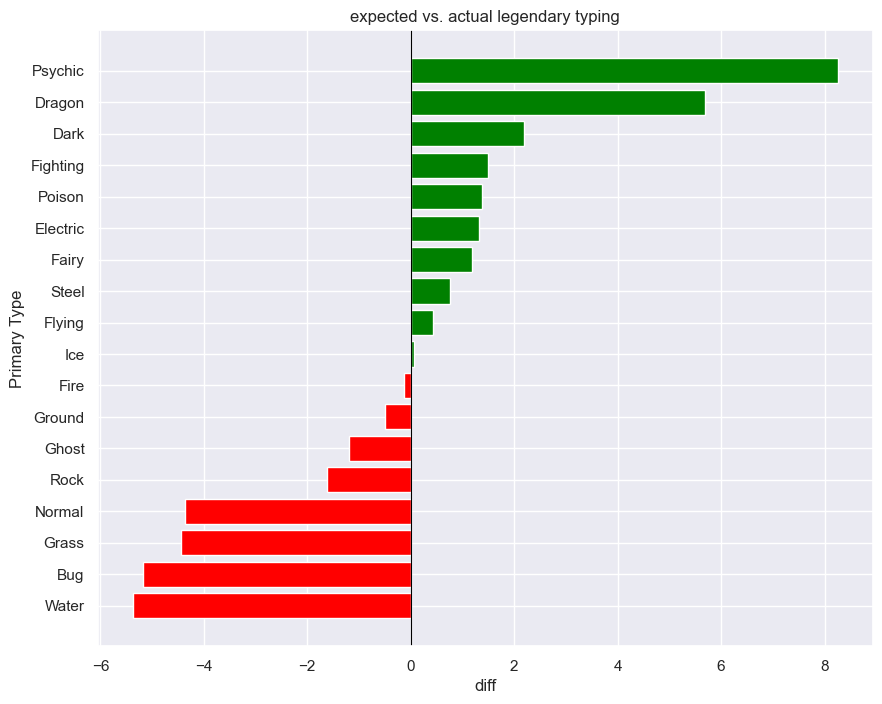

In [53]:
plt.figure(figsize=(10, 8))

colors = ['red' if x < 0 else 'green' for x in legendary_diff.values]

plt.barh(legendary_diff.index, legendary_diff.values, color = colors)

plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('expected vs. actual legendary typing')
plt.xlabel('diff')
plt.ylabel('Primary Type')
plt.savefig('/Users/prajwalhendre/Desktop/Pokemon_Project/expected_vs_actual_legendary_typing.png', dpi=300, bbox_inches='tight')
plt.show()